# 📐 Riconoscimento Griglia Scritta a Mano
Questo notebook:
1. Carica un'immagine con una griglia scritta a mano
2. Rileva automaticamente la griglia e le sue celle
3. Isola ogni cella come immagine
4. Passa ogni cella al tuo modello di riconoscimento lettere
5. Restituisce la matrice di caratteri riconosciuti

## 1. Import e configurazione

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ──────────────────────────────────────────────
#  CONFIG  – modifica questi parametri a piacere
# ──────────────────────────────────────────────
IMAGE_PATH     = 'griglia.jpg'   # percorso immagine
CELL_SIZE      = (28, 28)        # dimensione output cella (adatta al tuo modello)
DEBUG          = True            # mostra immagini intermedie

# Parametri preprocessing
BLUR_KERNEL    = (5, 5)          # kernel gaussian blur
CANNY_LOW      = 50              # soglia bassa Canny
CANNY_HIGH     = 150             # soglia alta Canny
DILATE_ITER    = 2               # iterazioni dilatazione linee
MIN_CELL_AREA  = 500             # area minima cella in pixel²

print('✅ Librerie caricate')

✅ Librerie caricate


## 2. Funzioni di rilevamento griglia

In [28]:
def load_image(path):
    """Carica e valida l'immagine."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Immagine non trovata: {path}")
    print(f"📷 Immagine caricata: {img.shape[1]}x{img.shape[0]} px")
    return img


def preprocess(img):
    """
    Pipeline di preprocessing:
    grayscale → blur → threshold adattivo → dilatazione
    Ritorna la maschera binaria delle linee.
    """
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)

    # Threshold adattivo: funziona bene anche con illuminazione non uniforme
    thresh  = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=15, C=4
    )

    # Dilata per connettere linee spezzate
    kernel  = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=DILATE_ITER)

    if DEBUG:
        _show([gray, thresh, dilated],
              ['Grayscale', 'Threshold', 'Dilatazione'])

    return gray, thresh, dilated


def detect_grid_lines(dilated):
    """
    Usa morfologia per estrarre SOLO le linee orizzontali e verticali,
    eliminando il testo scritto nelle celle.
    Ritorna la maschera binaria della griglia.
    """
    h, w = dilated.shape

    # Kernel orizzontale: almeno 1/20 della larghezza
    horiz_len   = max(w // 20, 30)
    horiz_k     = cv2.getStructuringElement(cv2.MORPH_RECT, (horiz_len, 1))
    horiz_lines = cv2.morphologyEx(dilated, cv2.MORPH_OPEN, horiz_k, iterations=2)

    # Kernel verticale: almeno 1/20 dell'altezza
    vert_len    = max(h // 20, 30)
    vert_k      = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vert_len))
    vert_lines  = cv2.morphologyEx(dilated, cv2.MORPH_OPEN, vert_k, iterations=2)

    grid_mask   = cv2.add(horiz_lines, vert_lines)

    if DEBUG:
        _show([horiz_lines, vert_lines, grid_mask],
              ['Linee orizzontali', 'Linee verticali', 'Griglia combinata'])

    return grid_mask


def find_cells(grid_mask, original_img):
    """
    Trova i contorni nella maschera invertita (le CELLE, non le linee).
    Filtra per area minima e ordinamento a griglia.
    Ritorna lista ordinata di bounding box (x, y, w, h) e griglia 2D.
    """
    # Inverti: celle = aree bianche nella maschera invertita
    inv_mask   = cv2.bitwise_not(grid_mask)
    contours, _ = cv2.findContours(
        inv_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        img_area = original_img.shape[0] * original_img.shape[1]
        # Filtra celle troppo piccole e l'intera immagine
        if area > MIN_CELL_AREA and area < img_area * 0.9:
            boxes.append((x, y, w, h))

    if not boxes:
        raise ValueError("❌ Nessuna cella trovata. Regola MIN_CELL_AREA o i parametri di threshold.")

    # Ordina: prima per riga (y), poi per colonna (x)
    # Raggruppa per riga usando tolleranza
    boxes_sorted = sorted(boxes, key=lambda b: (b[1], b[0]))
    grid_2d = _cluster_into_grid(boxes_sorted, 5)

    print(f"📊 Griglia rilevata: {len(grid_2d)} righe x {len(grid_2d[0])} colonne")
    return boxes_sorted, grid_2d


def _cluster_into_grid(boxes, y_tolerance=None):
    """
    Raggruppa i bounding box in righe della griglia.
    y_tolerance: pixel di tolleranza per considerare due celle sulla stessa riga.
    """
    if not boxes:
        return []

    # Tolleranza automatica: metà dell'altezza media delle celle
    if y_tolerance is None:
        avg_h = np.mean([b[3] for b in boxes])
        y_tolerance = avg_h * 0.5

    rows = []
    current_row = [boxes[0]]
    for box in boxes[1:]:
        if abs(box[1] - current_row[0][1]) < y_tolerance:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))  # ordina per x
            current_row = [box]
    rows.append(sorted(current_row, key=lambda b: b[0]))

    return rows


print('✅ Funzioni di rilevamento definite')

✅ Funzioni di rilevamento definite


## 3. Estrazione e preprocessing delle celle

In [29]:
def extract_cell(img_gray, box, padding=4, target_size=CELL_SIZE):
    """
    Ritaglia la cella dall'immagine in grayscale, aggiunge padding,
    ridimensiona al target_size del modello.
    """
    x, y, w, h = box
    H, W = img_gray.shape

    x1 = max(0, x + padding)
    y1 = max(0, y + padding)
    x2 = min(W, x + w - padding)
    y2 = min(H, y + h - padding)

    cell = img_gray[y1:y2, x1:x2]
    if cell.size == 0:
        return np.zeros(target_size, dtype=np.uint8)

    cell_resized = cv2.resize(cell, target_size, interpolation=cv2.INTER_AREA)
    return cell_resized


def extract_all_cells(img_gray, grid_2d, padding=4):
    """
    Estrae tutte le celle dalla griglia.
    Ritorna cells_2d: lista 2D di array numpy (una per ogni cella).
    """
    cells_2d = []
    for row in grid_2d:
        row_cells = [extract_cell(img_gray, box, padding) for box in row]
        cells_2d.append(row_cells)
    return cells_2d


def visualize_cells(cells_2d, max_cols=10):
    """Mostra le celle estratte come griglia di miniature."""
    n_rows = len(cells_2d)
    n_cols = min(len(cells_2d[0]), max_cols) if cells_2d else 0
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.2))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for r, row in enumerate(cells_2d[:n_rows]):
        for c, cell in enumerate(row[:n_cols]):
            axes[r, c].imshow(cell, cmap='gray')
            axes[r, c].axis('off')
            axes[r, c].set_title(f'{r},{c}', fontsize=7)

    plt.suptitle('Celle estratte', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


print('✅ Funzioni di estrazione celle definite')

✅ Funzioni di estrazione celle definite


## 4. Interfaccia modello — plug-in qualsiasi modello qui

In [30]:
from tensorflow import keras
model = keras.models.load_model('models/opt_pretrained_model.keras')

LABELS = list('BGTY')

def predict_cell(cell_img):
    inp = cell_img.astype('float32') / 255.0
    inp = inp.reshape(1, *CELL_SIZE, 1)   # aggiusta i canali se servono 3
    probs = model.predict(inp, verbose=0)[0]
    return LABELS[np.argmax(probs)]



print('✅ Interfaccia modello pronta (usa il placeholder finché non carichi il tuo)')

✅ Interfaccia modello pronta (usa il placeholder finché non carichi il tuo)


## 5. Funzioni di supporto visualizzazione

In [31]:
def _show(imgs, titles=None, cmap='gray'):
    """Utility: mostra una lista di immagini affiancate."""
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap)
        ax.axis('off')
        if titles:
            ax.set_title(titles[i], fontsize=10)
    plt.tight_layout()
    plt.show()


def draw_detected_cells(img, grid_2d):
    """Disegna i bounding box delle celle sull'immagine originale."""
    vis = img.copy()
    colors = [(0,200,100), (100,100,255), (255,100,0), (0,200,255)]
    for r, row in enumerate(grid_2d):
        for c, (x, y, w, h) in enumerate(row):
            color = colors[r % len(colors)]
            cv2.rectangle(vis, (x, y), (x+w, y+h), color, 2)
            cv2.putText(vis, f'{r},{c}', (x+4, y+16),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    _show([vis], ['Celle rilevate'])


def print_matrix(matrix):
    """Stampa la matrice in modo leggibile."""
    print("\n📋 MATRICE RICONOSCIUTA:")
    print("  " + "  ".join(str(j) for j in range(len(matrix[0]))))
    print("  " + "──" * len(matrix[0]))
    for i, row in enumerate(matrix):
        print(f"{i} │ " + "  ".join(str(c) for c in row))
    print()
    return matrix


print('✅ Funzioni di visualizzazione definite')

✅ Funzioni di visualizzazione definite


## 6. Pipeline principale

In [32]:
def process_grid(image_path, predict_fn=predict_cell, cell_padding=4):
    """
    Pipeline completa:
    immagine → preprocessing → rilevamento griglia → estrazione celle
    → classificazione → matrice di caratteri

    Parametri:
        image_path : str     – percorso dell'immagine
        predict_fn : callable – funzione predict_cell (scambiabile)
        cell_padding : int   – pixel da togliere ai bordi di ogni cella

    Ritorna:
        matrix : list[list[str]]  – matrice dei caratteri riconosciuti
        cells_2d : list[list[np.ndarray]] – celle estratte
    """
    print("=" * 50)
    print("🔍 STEP 1/5 – Caricamento immagine")
    img = load_image(image_path)

    print("\n🔍 STEP 2/5 – Preprocessing")
    gray, thresh, dilated = preprocess(img)

    print("\n🔍 STEP 3/5 – Rilevamento linee griglia")
    grid_mask = detect_grid_lines(dilated)

    print("\n🔍 STEP 4/5 – Individuazione celle")
    boxes_sorted, grid_2d = find_cells(grid_mask, img)
    if DEBUG:
        draw_detected_cells(img, grid_2d)

    print("\n🔍 STEP 5/5 – Estrazione e classificazione celle")
    cells_2d = extract_all_cells(gray, grid_2d, padding=cell_padding)

    if DEBUG:
        visualize_cells(cells_2d)

    # Classificazione
    matrix = []
    for r, row_cells in enumerate(cells_2d):
        row_labels = []
        for c, cell in enumerate(row_cells):
            label = predict_fn(cell)
            row_labels.append(label)
        matrix.append(row_labels)
        print(f"  Riga {r}: {row_labels}")

    print("=" * 50)
    print_matrix(matrix)
    return matrix, cells_2d


print('✅ Pipeline principale definita')

✅ Pipeline principale definita


## 7. Esecuzione

🔍 STEP 1/5 – Caricamento immagine
📷 Immagine caricata: 400x400 px

🔍 STEP 2/5 – Preprocessing


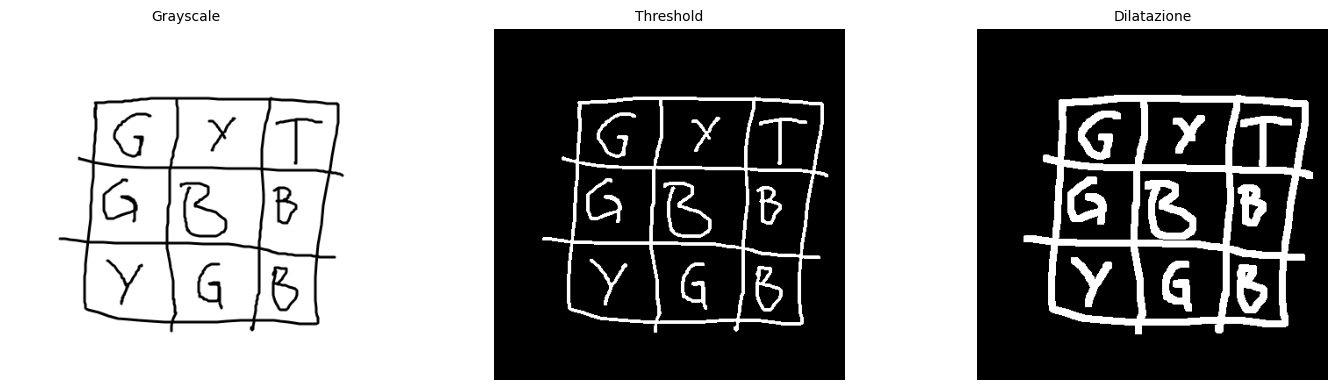


🔍 STEP 3/5 – Rilevamento linee griglia


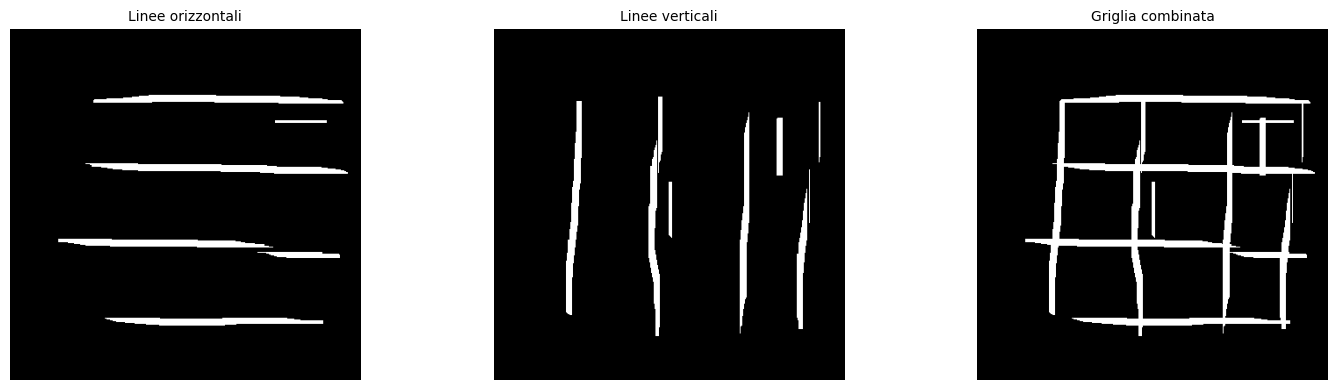


🔍 STEP 4/5 – Individuazione celle
📊 Griglia rilevata: 6 righe x 1 colonne


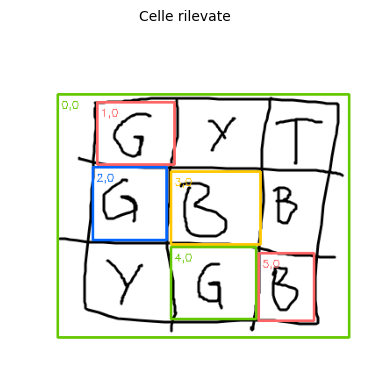


🔍 STEP 5/5 – Estrazione e classificazione celle


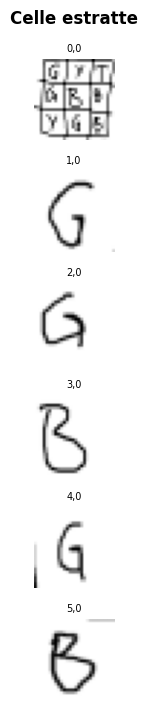

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(1, 28, 28, 1), dtype=float32). Expected shape (None, 784), but input has incompatible shape (1, 28, 28, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 28, 28, 1), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [36]:
# ── Carica qui il tuo modello reale ──────────────────────
# (decommenta la sezione appropriata nella cella 4)
# ─────────────────────────────────────────────────────────

matrix, cells = process_grid(
    image_path  = "grid_imgs/image1.png",
    predict_fn  = predict_cell,   # ← scambia con qualsiasi callable
    cell_padding = 4
)

## 8. Accesso ai risultati

In [ ]:
# Accesso diretto alla matrice
print("Elemento [0][0]:", matrix[0][0])
print("Intera riga 1:", matrix[1] if len(matrix) > 1 else 'N/A')

# Conversione a numpy per elaborazioni successive
import numpy as np
np_matrix = np.array(matrix)
print("\nMatrice numpy:\n", np_matrix)

# Ispeziona una singola cella
r, c = 0, 0
plt.figure(figsize=(2, 2))
plt.imshow(cells[r][c], cmap='gray')
plt.title(f'Cella [{r},{c}] → "{matrix[r][c]}"')
plt.axis('off')
plt.show()

## 9. Tuning parametri (se la griglia non viene rilevata bene)

In [ ]:
# ─── Regola interattivamente i parametri principali ───────
#
# Se le celle non vengono trovate:
#   MIN_CELL_AREA troppo alto → abbassalo
#   DILATE_ITER troppo basso → aumentalo se le linee sono spezzate
#
# Se vengono trovate troppe regioni:
#   MIN_CELL_AREA troppo basso → alzalo
#   BLUR_KERNEL più grande aiuta a ridurre il rumore
#
# Per griglia molto irregolare: aumenta y_tolerance in _cluster_into_grid
#
# ─── Testa il solo step di rilevamento ───────────────────

img_test  = load_image(IMAGE_PATH)
gray_t, thresh_t, dilated_t = preprocess(img_test)
mask_t    = detect_grid_lines(dilated_t)

# Visualizza la maschera finale della griglia
_show([img_test, mask_t], ['Originale', 'Maschera griglia'])